In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# -------------------------------------------------
# Create Environment
# -------------------------------------------------
env_desc = [
    "SFFF",
    "FHFH",
    "FFFH",
    "HFFG"
]

env = gym.make(
    "FrozenLake-v1",
    desc=env_desc,
    is_slippery=True
)

n_states = env.observation_space.n
n_actions = env.action_space.n


In [3]:
# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------
num_episodes = 20000
gamma = 0.99
alpha = 0.1

epsilon_start = 1.0
epsilon_min = 0.05
epsilon_decay = 0.9995

max_steps_per_episode = 100

In [5]:

# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------
Q = np.zeros((n_states, n_actions))
episode_rewards = []


# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------
def epsilon_greedy_action(state, epsilon):

    if np.random.random() < epsilon:
        # Exploration
        return env.action_space.sample()
    else:
        # Exploitation
        return np.argmax(Q[state])




In [6]:

# -------------------------------------------------
# Generate One Complete Episode
# -------------------------------------------------
def generate_episode(epsilon):
    """
    Generates one episode using the current
    epsilon-greedy policy.
    Returns a list of (state, action, reward).
    """

    episode = []

    state, info = env.reset()

    for _ in range(max_steps_per_episode):

        action = epsilon_greedy_action(state, epsilon)

        next_state, reward, terminated, truncated, info = env.step(action)

        episode.append((state, action, reward))

        state = next_state

        if terminated or truncated:
            break

    return episode



In [7]:

# -------------------------------------------------
# Monte Carlo Control
# -------------------------------------------------
epsilon = epsilon_start

for episode_num in range(num_episodes):

    # Generate one complete episode
    episode = generate_episode(epsilon)

    # Calculate total reward of the episode
    total_reward = sum(
        reward for state, action, reward in episode
    )

    episode_rewards.append(total_reward)

    # Calculate returns backward
    G = 0

    for state, action, reward in reversed(episode):

        G = reward + gamma * G

        # Incremental Monte Carlo update
        Q[state, action] += alpha * (
            G - Q[state, action]
        )

    # Decay epsilon
    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )



In [8]:

# -------------------------------------------------
# Extract Greedy Policy
# -------------------------------------------------
optimal_policy = np.argmax(Q, axis=1)
state_values = np.max(Q, axis=1)

In [9]:

# -------------------------------------------------
# Display Results
# -------------------------------------------------
def print_policy(policy):

    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)

    print("Name: Suresh S")
    print("Register Number: 212223040215")

    print("\nLearned Policy:")
    print(policy_grid)


def print_value_function(values):

    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(optimal_policy)

success_rate = np.mean(episode_rewards[-1000:])

print(
    "\nAverage reward over last 1000 episodes:",
    success_rate
)



Final Q-table:
[[0.    0.    0.    0.219]
 [0.    0.083 0.    0.   ]
 [0.001 0.    0.232 0.   ]
 [0.167 0.086 0.    0.   ]
 [0.    0.    0.005 0.   ]
 [0.    0.    0.    0.   ]
 [0.001 0.001 0.183 0.001]
 [0.    0.    0.    0.   ]
 [0.    0.031 0.005 0.   ]
 [0.028 0.025 0.235 0.024]
 [0.376 0.047 0.075 0.014]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.066 0.289 0.157 0.172]
 [0.237 0.301 0.642 0.417]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.219 0.083 0.232 0.167]
 [0.005 0.    0.183 0.   ]
 [0.031 0.235 0.376 0.   ]
 [0.    0.289 0.642 0.   ]]
Name: Suresh S
Register Number: 212223040215

Learned Policy:
[['U' 'D' 'R' 'L']
 ['R' 'L' 'R' 'L']
 ['D' 'R' 'L' 'L']
 ['L' 'D' 'R' 'L']]

Average reward over last 1000 episodes: 0.035


Suresh S
212223040215


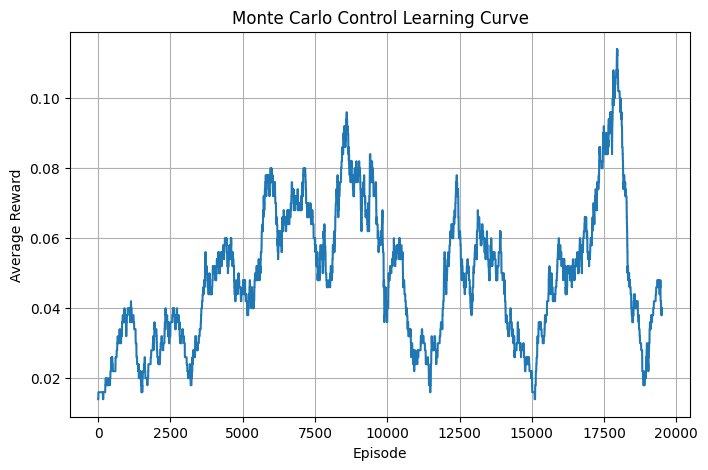

In [12]:


print("Suresh S")
print("212223040215")

# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------
window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Monte Carlo Control Learning Curve")
plt.grid(True)
plt.show()

env.close()